# K-Means Algorithm

K-Means is an unsupervised machine learning algorithm used for clustering data into distinct groups. It automatically identifies patterns in the data without predefined labels, organizing data points into K clusters based on their similarities. This makes it useful for discovering hidden structures in large datasets.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

In [10]:
data=pd.read_excel('Wholesale_Customers_Dataset.xlsx')

In [11]:
data.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,1,3,14931,598,5014,5408,517,3586
1,2,2,4627,2700,12093,4170,8406,1910
2,1,2,17157,14672,19070,4899,8908,3023
3,1,2,11173,3461,4009,1570,4074,5401
4,1,2,19047,14707,17538,680,3367,2314


In [12]:
#display basic information about the dataset
data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           100 non-null    int64
 1   Region            100 non-null    int64
 2   Fresh             100 non-null    int64
 3   Milk              100 non-null    int64
 4   Grocery           100 non-null    int64
 5   Frozen            100 non-null    int64
 6   Detergents_Paper  100 non-null    int64
 7   Delicassen        100 non-null    int64
dtypes: int64(8)
memory usage: 6.4 KB


In [13]:
#summary statistics of dataset
data.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,1.560000,2.040000,10426.48000,7286.270000,13735.270000,4066.730000,5195.740000,3231.160000
std,0.498888,0.863631,5520.25027,4374.127115,7019.800836,2008.065016,2790.466601,1685.853797
min,1.000000,1.000000,1197.00000,598.000000,1784.000000,435.000000,495.000000,109.000000
25%,1.000000,1.000000,5882.50000,3787.750000,7924.250000,2539.750000,2856.750000,1668.500000
50%,2.000000,2.000000,10273.50000,6558.500000,14152.500000,3929.500000,5327.000000,3427.000000
75%,2.000000,3.000000,15117.00000,11186.750000,19466.250000,5540.000000,7467.750000,4856.000000
max,2.000000,3.000000,19895.00000,14934.000000,24944.000000,7844.000000,9979.000000,5895.000000


In [14]:
# Import StandardScaler from sklearn preprocessing
# StandardScaler is used to scale/normalize numerical data
# It converts data so that:
# Mean = 0
# Standard Deviation = 1

from sklearn.preprocessing import StandardScaler
# Create an object (instance) of StandardScaler

scaler = StandardScaler()
# Fit and transform the data
# fit() → learns mean and standard deviation from data
# transform() → applies scaling to data
# fit_transform() → does both in one step

data_scaled = scaler.fit_transform(data)
# Convert scaled data into DataFrame and describe it
# pd.DataFrame() → converts numpy array to dataframe
# describe() → shows statistics (mean, std, min, max, etc.)

pd.DataFrame(data_scaled).describe()

,0,1,2,3,4,5,6,7
count,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02
mean,-7.105427e-17,1.526557e-17,3.441691e-17,-1.437739e-16,-6.439294e-17,-1.720846e-17,6.328271e-17,7.327472e-17
std,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00
min,-1.128152e+00,-1.210285e+00,-1.680354e+00,-1.536756e+00,-1.711085e+00,-1.817683e+00,-1.693058e+00,-1.861305e+00
25%,-1.128152e+00,-1.210285e+00,-8.272943e-01,-8.038506e-01,-8.319744e-01,-7.642545e-01,-8.424302e-01,-9.315947e-01
50%,8.864053e-01,-4.654941e-02,-2.785212e-02,-1.672188e-01,5.973559e-02,-6.868370e-02,4.727570e-02,1.167519e-01
75%,8.864053e-01,1.117186e+00,8.539740e-01,8.962085e-01,8.205150e-01,7.373726e-01,8.183061e-01,9.686639e-01
max,8.864053e-01,1.117186e+00,1.723875e+00,1.757210e+00,1.604775e+00,1.890526e+00,1.722779e+00,1.588074e+00


In [23]:
kmeans=KMeans(n_clusters = 2,init ='k-means++')
                   # Import KMeans clustering algorithm
                   # KMeans is an unsupervised learning algorithm used for clustering
kmeans.fit(data_scaled)
                  # n_clusters = 2 → divide data into 2 clusters
                  # init = 'k-means++' → smart method to choose initial cluster centers
                  # Train (fit) KMeans model using scaled data
                  # data_scaled → scaled dataset using StandardScaler

kmeans.inertia_
                 # inertia_ gives the total distance of points from their cluster center
                 # Lower inertia means better clustering



714.8334432629722

### Step 1: Empty List
wcss = [ ]

➡️ Create an empty list to store values of WCSS (inertia)

### Step 2: Loop Starts
for cluster in range(1,21):

This means:

Start from 1
End at 20
Run loop 20 times

So cluster values will be:

1, 2, 3, 4, 5 ... 20

### Step 3: First Loop (cluster = 1)
kmeans = KMeans(n_clusters=1, init='k-means++')
kmeans.fit(data_scaled)
wcss.append(kmeans.inertia_)

➡️ Model creates 1 cluster
➡️ Calculate inertia
➡️ Store value in list

Example:

wcss = [5000]

### Step 4: Second Loop (cluster = 2)
kmeans = KMeans(n_clusters=2)

➡️ Model creates 2 clusters
➡️ Calculate inertia
➡️ Add to list

Example:

wcss = [5000, 3000]

### Step 5: Third Loop (cluster = 3)

Example:

wcss = [5000, 3000, 2000]
Loop Continues Until 20

Final Example:

wcss = [5000, 3000, 2000, 1500, 1200, 1000, ...]

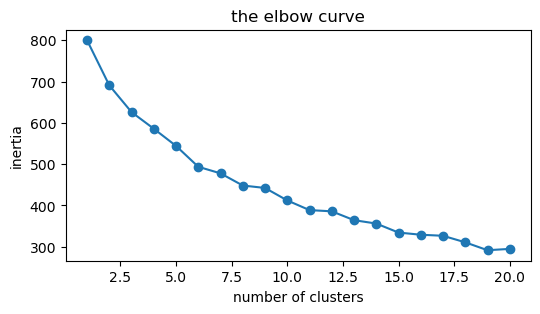

In [29]:
wcss=[] #list

for cluster in range(1,21):
    kmeans=KMeans(n_clusters=cluster,init='k-means++')
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,3))
plt.plot(range(1, 21), wcss, marker='o')
plt.title('the elbow curve')
plt.xlabel('number of clusters')
plt.ylabel('inertia')
plt.show()


In [30]:
#build the model with the 6 clusters

kmeans = KMeans(n_clusters = 6, init = 'k-means++')
kmeans.fit(data_scaled)
pred = kmeans.predict(data_scaled)

df = pd.DataFrame(data_scaled)
df.head()

,0,1,2,3,4,5,6,7
0,-1.128152,1.117186,0.820110,-1.536756,-1.248640,0.671306,-1.685134,0.211541
1,0.886405,-0.046549,-1.055875,-1.053782,-0.235127,0.051687,1.156234,-0.787622
2,-1.128152,-0.046549,1.225384,1.697010,0.763783,0.416552,1.337039,-0.124097
3,-1.128152,-0.046549,0.135914,-0.878928,-1.392528,-1.249615,-0.404015,1.293571
4,-1.128152,-0.046549,1.569485,1.705052,0.544444,-1.695061,-0.658654,-0.546774


In [40]:
df['Cluster'] = pred
df.head()

,0,1,2,3,4,5,6,7,Cluster
0,-1.128152,1.117186,0.820110,-1.536756,-1.248640,0.671306,-1.685134,0.211541,0
1,0.886405,-0.046549,-1.055875,-1.053782,-0.235127,0.051687,1.156234,-0.787622,4
2,-1.128152,-0.046549,1.225384,1.697010,0.763783,0.416552,1.337039,-0.124097,2
3,-1.128152,-0.046549,0.135914,-0.878928,-1.392528,-1.249615,-0.404015,1.293571,4
4,-1.128152,-0.046549,1.569485,1.705052,0.544444,-1.695061,-0.658654,-0.546774,2


In [41]:
df.tail()

,0,1,2,3,4,5,6,7,Cluster
95,0.886405,-1.210285,-0.707769,-1.123861,0.005688,-1.597463,-0.282278,-0.770930,3
96,0.886405,-0.046549,0.038328,-0.931315,1.582440,1.392027,-1.358461,-0.707737,0
97,0.886405,-1.210285,1.121426,-0.671676,0.502351,1.574710,1.531169,-1.861305,2
98,0.886405,-1.210285,-1.250684,1.407731,0.064246,-1.172037,-0.704036,-0.155097,3
99,-1.128152,-0.046549,-0.698120,0.153653,-1.344709,-0.449314,0.836765,-1.391532,4


In [42]:
df.head(20)

,0,1,2,3,4,5,6,7,Cluster
0,-1.128152,1.117186,0.820110,-1.536756,-1.248640,0.671306,-1.685134,0.211541,0
1,0.886405,-0.046549,-1.055875,-1.053782,-0.235127,0.051687,1.156234,-0.787622,4
2,-1.128152,-0.046549,1.225384,1.697010,0.763783,0.416552,1.337039,-0.124097,2
3,-1.128152,-0.046549,0.135914,-0.878928,-1.392528,-1.249615,-0.404015,1.293571,4
4,-1.128152,-0.046549,1.569485,1.705052,0.544444,-1.695061,-0.658654,-0.546774,2
5,0.886405,-0.046549,0.146292,-0.416633,-0.287241,1.484620,-1.538185,0.628853,0
6,-1.128152,-0.046549,1.143455,-0.540708,-1.621603,1.520156,0.926447,-1.441609,2
7,-1.128152,1.117186,0.376421,1.190830,-0.069620,-0.837202,0.233843,0.280696,1
8,-1.128152,1.117186,-1.478446,-0.900066,-1.711085,-0.410275,1.661190,0.597853,4
9,0.886405,-0.046549,-0.482556,1.066065,-0.664213,0.141276,-1.686935,0.233003,3


In [45]:
df['cluster'] = pred
df['cluster'].value_counts()

cluster
2    24
1    19
3    16
0    15
4    13
5    13
Name: count, dtype: int64

In [49]:
# Function to take input, standardize it, and predict the cluster
def get_cluster_prediction():

    # Collecting user input for each feature
    Channel = int(input("Enter Channel (e.g., 1, 2): "))
    Region = int(input("Enter Region (e.g., 1, 2, 3): "))
    Fresh = float(input("Enter annual spending on Fresh products: "))
    Milk = float(input("Enter annual spending on Milk: "))
    Grocery = float(input("Enter annual spending on Grocery: "))
    Frozen = float(input("Enter annual spending on Frozen products: "))
    Detergents_Paper = float(input("Enter annual spending on Detergents_Paper: "))
    Delicassen = float(input("Enter annual spending on Delicassen: "))

    # Create a data point with the input values
    user_data = np.array([[Channel, Region, Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen]])

    # Standardize the user input using the already fitted scaler
    user_data_scaled = scaler.transform(user_data)

    # Predict the cluster using the clustering model
    cluster = kmeans.predict(user_data_scaled)

    # Output the predicted cluster
    print(f"The customer belongs to cluster: {cluster[0]}")

In [50]:
get_cluster_prediction()

Enter Channel (e.g., 1, 2):  1
Enter Region (e.g., 1, 2, 3):  3
Enter annual spending on Fresh products:  25456
Enter annual spending on Milk:  9000
Enter annual spending on Grocery:  2
Enter annual spending on Frozen products:  2500
Enter annual spending on Detergents_Paper:  522
Enter annual spending on Delicassen:  250


The customer belongs to cluster: 2
